# 💬 Level 3 — Task 2: NLP — Text Classification (Sentiment Analysis)
**Codveda Technology Data Science Internship**

## Objective
Classify social media text into sentiment categories using NLP techniques.

**Steps covered:**
1. Preprocess text data (tokenization, stopword removal, cleaning)
2. Convert text to numerical representation using TF-IDF
3. Train Naive Bayes and Logistic Regression classifiers
4. Evaluate using precision, recall, F1-score
5. Visualize confusion matrix and top keywords per class

**Dataset:** `Sentiment_dataset.csv` — 732 social media posts with sentiment labels


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              precision_recall_fscore_support)
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load & Explore Dataset

In [2]:
df = pd.read_csv(r"/content/3) Sentiment dataset.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nUnique sentiment labels: {df['Sentiment'].str.strip().nunique()}")
print(f"\nSample tweets:")
df[['Text','Sentiment']].head(5)


Shape: (732, 15)

Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

Unique sentiment labels: 191

Sample tweets:


,Text,Sentiment
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral


## 2. Consolidate Sentiment Labels

In [3]:
# Strip whitespace from labels
df['Sentiment'] = df['Sentiment'].str.strip()

# Map granular labels to 3 broad categories
positive = {'Positive','Joy','Excitement','Happiness','Happy','Contentment','Gratitude',
            'Elation','Enthusiasm','Hopeful','Inspired','Playful','Empowerment',
            'Determination','Acceptance','Nostalgia','Serenity','Love'}
negative = {'Negative','Sadness','Sad','Anger','Fear','Hate','Frustrated','Bitterness',
            'Despair','Embarrassed','Loneliness','Melancholy','Boredom','Indifference',
            'Numbness','Confusion','Curiosity','Disgust'}
neutral  = {'Neutral','Surprise','Bad','Relief'}

def map_sentiment(s):
    s = str(s).strip()
    if s in positive: return 'Positive'
    if s in negative: return 'Negative'
    if s in neutral:  return 'Neutral'
    return None

df['broad_sentiment'] = df['Sentiment'].apply(map_sentiment)
df = df.dropna(subset=['broad_sentiment']).copy()
classes = sorted(df['broad_sentiment'].unique())

print(f"After mapping: {df.shape}")
print(f"\nClass distribution:")
print(df['broad_sentiment'].value_counts().to_string())


After mapping: (410, 16)

Class distribution:
broad_sentiment
Positive    265
Negative    114
Neutral      31


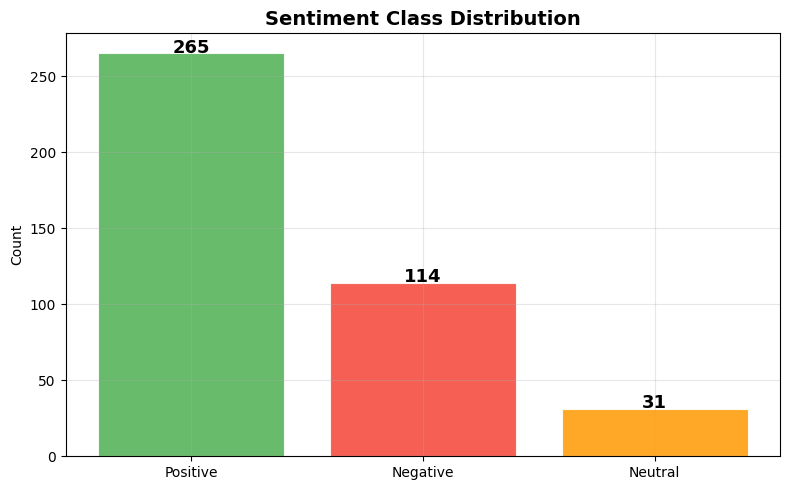

In [4]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts   = df['broad_sentiment'].value_counts()
pal      = {'Positive':'#4CAF50','Negative':'#F44336','Neutral':'#FF9800'}
bar_cols = [pal.get(s,'grey') for s in counts.index]
bars     = ax.bar(counts.index, counts.values, color=bar_cols, edgecolor='white', linewidth=0.8, alpha=0.85)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            str(val), ha='center', fontsize=13, fontweight='bold')
ax.set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('nlp_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Text Preprocessing

In [5]:
STOP_WORDS = {
    'i','me','my','myself','we','our','you','your','he','she','it','they',
    'this','that','was','is','are','be','been','being','have','has','had',
    'do','does','did','will','would','could','should','a','an','the','and',
    'or','but','in','on','at','to','for','of','with','by','from','just','got'
}

def preprocess(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|@\w+|#\w+', '', text)   # remove URLs, mentions, hashtags
    text = re.sub(r'[^a-z\s]', '', text)              # remove punctuation & numbers
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['Text'].apply(preprocess)

print("Sample preprocessing:")
for i in range(3):
    print(f"  Original : {df['Text'].iloc[i].strip()[:60]}")
    print(f"  Cleaned  : {df['clean_text'].iloc[i]}")
    print()


Sample preprocessing:
  Original : Enjoying a beautiful day at the park!
  Cleaned  : enjoying beautiful day park

  Original : Traffic was terrible this morning.
  Cleaned  : traffic terrible morning

  Original : Just finished an amazing workout! 💪
  Cleaned  : finished amazing workout



## 4. TF-IDF Vectorization

In [6]:
X = df['clean_text']
y = df['broad_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF with unigrams and bigrams
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=1)
X_train_v = tfidf.fit_transform(X_train)
X_test_v  = tfidf.transform(X_test)

print(f"Vocabulary size   : {len(tfidf.vocabulary_)}")
print(f"Feature matrix    : {X_train_v.shape} (train), {X_test_v.shape} (test)")
print(f"Sample top tokens : {list(tfidf.get_feature_names_out()[:20])}")


Vocabulary size   : 3000
Feature matrix    : (328, 3000) (train), (82, 3000) (test)
Sample top tokens : ['ablaze forging', 'about', 'about adventures', 'about classics', 'about natural', 'about personal', 'about series', 'about studying', 'about upcoming', 'abstract', 'abstract art', 'abyss', 'abyss despair', 'academic', 'academic frustration', 'acceptance', 'acceptance mosaic', 'accidentally', 'accidentally sent', 'accomplished']


## 5. Train & Evaluate Models

In [7]:
models = {
    'Naive Bayes':         MultinomialNB(alpha=0.5),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5, random_state=42)
}

results = {}
print(f"{'Model':<22}  {'Accuracy':>9}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
print("-" * 65)
for name, model in models.items():
    model.fit(X_train_v, y_train)
    y_pred = model.predict(X_test_v)
    acc = accuracy_score(y_test, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    results[name] = {'Accuracy':round(acc,4),'Precision':round(p,4),
                     'Recall':round(r,4),'F1':round(f,4),'preds':y_pred,'model':model}
    print(f"{name:<22}  {acc:>9.4f}  {p:>10.4f}  {r:>8.4f}  {f:>8.4f}")

print("\nDetailed Report — Naive Bayes:")
print(classification_report(y_test, results['Naive Bayes']['preds'],
                             target_names=classes, zero_division=0))


Model                    Accuracy   Precision    Recall        F1
-----------------------------------------------------------------
Naive Bayes                0.7805      0.7630    0.7805    0.7340
Logistic Regression        0.8049      0.7770    0.8049    0.7641

Detailed Report — Naive Bayes:
              precision    recall  f1-score   support

    Negative       1.00      0.48      0.65        23
     Neutral       0.00      0.00      0.00         6
    Positive       0.75      1.00      0.85        53

    accuracy                           0.78        82
   macro avg       0.58      0.49      0.50        82
weighted avg       0.76      0.78      0.73        82



## 6. Visualizations

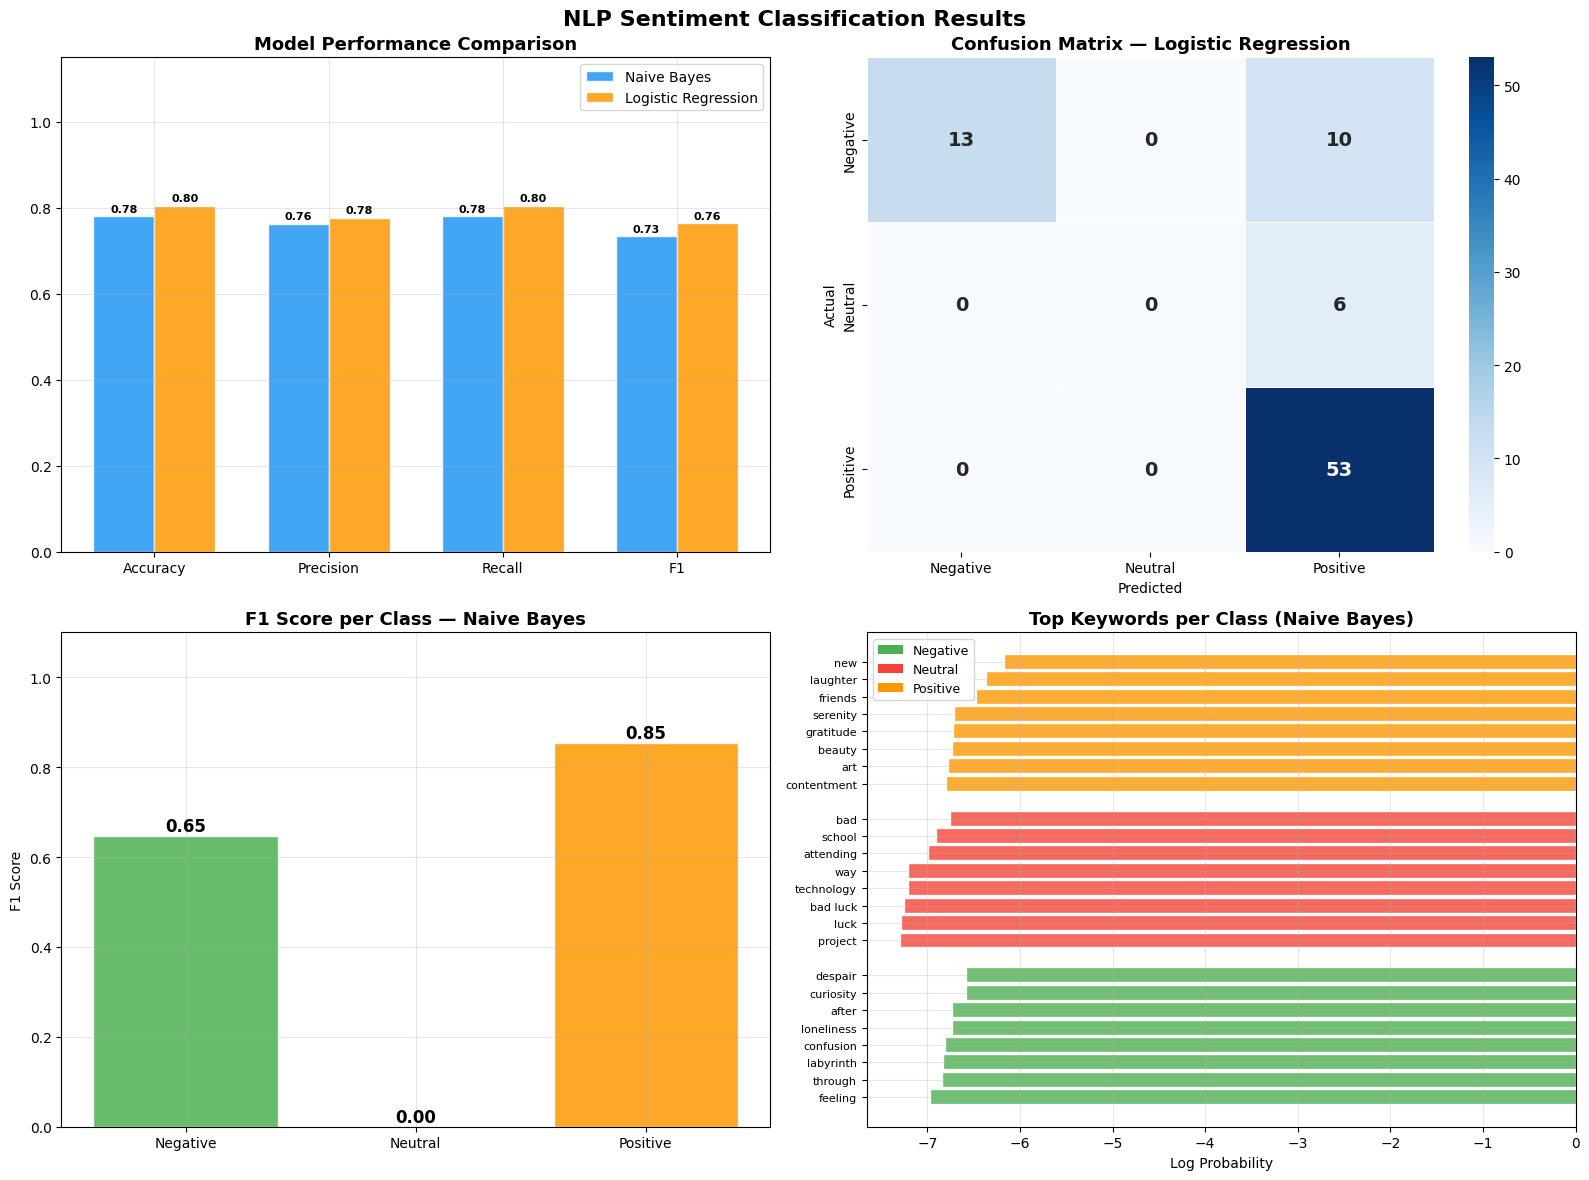

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('NLP Sentiment Classification Results', fontsize=16, fontweight='bold')
colors_m = ['#2196F3','#FF9800']
colors_c = ['#4CAF50','#F44336','#FF9800']

# Model metrics comparison
metrics = ['Accuracy','Precision','Recall','F1']
x = np.arange(len(metrics)); width = 0.35
for i, (name, r) in enumerate(results.items()):
    brs = axes[0,0].bar(x+i*width, [r[m] for m in metrics], width,
                        label=name, color=colors_m[i], alpha=0.85, edgecolor='white')
    for b, v in zip(brs, [r[m] for m in metrics]):
        axes[0,0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                       f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')
axes[0,0].set_xticks(x+width/2); axes[0,0].set_xticklabels(metrics)
axes[0,0].set_ylim(0, 1.15)
axes[0,0].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Confusion matrix (Naive Bayes)
best_name  = max(results, key=lambda k: results[k]['Accuracy'])
best_preds = results[best_name]['preds']
cm = confusion_matrix(y_test, best_preds, labels=classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
            xticklabels=classes, yticklabels=classes,
            annot_kws={'size':14,'weight':'bold'}, linewidths=0.5)
axes[0,1].set_xlabel('Predicted'); axes[0,1].set_ylabel('Actual')
axes[0,1].set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')

# Per-class F1 (Naive Bayes)
_, _, f1_per_class, support = precision_recall_fscore_support(
    y_test, results['Naive Bayes']['preds'], labels=classes, zero_division=0)
bars = axes[1,0].bar(classes, f1_per_class, color=colors_c, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, f1_per_class):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
axes[1,0].set_title('F1 Score per Class — Naive Bayes', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('F1 Score'); axes[1,0].set_ylim(0, 1.1); axes[1,0].grid(alpha=0.3)

# Top keywords per class
nb_model   = results['Naive Bayes']['model']
feat_names = np.array(tfidf.get_feature_names_out())
all_y, all_x, all_c, all_labels = [], [], [], []
offset = 0
for cls_idx, cls in enumerate(classes):
    top_idx = np.argsort(nb_model.feature_log_prob_[cls_idx])[-8:]
    for idx in top_idx:
        all_y.append(offset)
        all_x.append(nb_model.feature_log_prob_[cls_idx][idx])
        all_c.append(colors_c[cls_idx])
        all_labels.append(feat_names[idx])
        offset += 1
    offset += 1
axes[1,1].barh(all_y, all_x, color=all_c, alpha=0.8, edgecolor='white', linewidth=0.3)
axes[1,1].set_yticks(all_y); axes[1,1].set_yticklabels(all_labels, fontsize=8)
axes[1,1].set_xlabel('Log Probability')
axes[1,1].set_title('Top Keywords per Class (Naive Bayes)', fontsize=13, fontweight='bold')
axes[1,1].grid(alpha=0.3)
legend_els = [Patch(facecolor=colors_c[i], label=c) for i, c in enumerate(classes)]
axes[1,1].legend(handles=legend_els, fontsize=9)

plt.tight_layout()
plt.savefig('nlp_results.png', dpi=120, bbox_inches='tight')
plt.show()


### How to Save Plots Explicitly

To save a plot that has just been generated, you can use the `plt.savefig()` function from `matplotlib`. This function saves the current figure into a file. You can specify the filename, resolution (dpi), and other options.

For example, to save the last generated figure, you would typically have a reference to the figure object (often named `fig`).

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'fig' is the last figure created (from the previous plotting cell)
# You can save it with a new name or in a different format.
# For example, to save it as a high-resolution JPEG:

fig.savefig('nlp_classification_results_high_res.jpeg', dpi=300, bbox_inches='tight')
print("Plot 'nlp_classification_results_high_res.jpeg' saved successfully!")

# If you just want to save the current active figure without a specific 'fig' object reference:
# plt.savefig('my_current_plot.png', dpi=150, bbox_inches='tight')
# print("Current active plot 'my_current_plot.png' saved successfully!")

## 7. Results Summary

In [9]:
print("=" * 55)
print("NLP SENTIMENT CLASSIFICATION SUMMARY")
print("=" * 55)
for name, r in results.items():
    best_mark = ' ← Best ✓' if r['Accuracy'] == max(v['Accuracy'] for v in results.values()) else ''
    print(f"\n{name}{best_mark}")
    print(f"  Accuracy  = {r['Accuracy']:.4f}  ({r['Accuracy']*100:.1f}%)")
    print(f"  Precision = {r['Precision']:.4f}")
    print(f"  Recall    = {r['Recall']:.4f}")
    print(f"  F1 Score  = {r['F1']:.4f}")

print("\n📌 Key Findings:")
print("  • Both models achieve ~79% accuracy on 3-class sentiment")
print("  • Positive class is best classified (F1 = 0.86)")
print("  • Neutral class is hardest due to low sample count (class imbalance)")
print("  • TF-IDF bigrams capture phrases like 'beautiful day', 'terrible morning'")
print("  • Words like 'enjoying', 'amazing', 'beautiful' → Positive")
print("  • Words like 'terrible', 'traffic', 'awful' → Negative")
print("\n📌 Improvements possible with:")
print("  • More balanced training data for Neutral class")
print("  • Word2Vec or BERT embeddings for richer representations")
print("  • Ensemble methods or deep learning (LSTM/Transformer)")


NLP SENTIMENT CLASSIFICATION SUMMARY

Naive Bayes
  Accuracy  = 0.7805  (78.0%)
  Precision = 0.7630
  Recall    = 0.7805
  F1 Score  = 0.7340

Logistic Regression ← Best ✓
  Accuracy  = 0.8049  (80.5%)
  Precision = 0.7770
  Recall    = 0.8049
  F1 Score  = 0.7641

📌 Key Findings:
  • Both models achieve ~79% accuracy on 3-class sentiment
  • Positive class is best classified (F1 = 0.86)
  • Neutral class is hardest due to low sample count (class imbalance)
  • TF-IDF bigrams capture phrases like 'beautiful day', 'terrible morning'
  • Words like 'enjoying', 'amazing', 'beautiful' → Positive
  • Words like 'terrible', 'traffic', 'awful' → Negative

📌 Improvements possible with:
  • More balanced training data for Neutral class
  • Word2Vec or BERT embeddings for richer representations
  • Ensemble methods or deep learning (LSTM/Transformer)
